Name:- Asha Bhokare

Roll no.:- 23012A0032

R-PROGRAMMING LAB 6

# Lab Problem Statement 6: Statistical Analysis of Palmer Penguins

R Programming Lab — Descriptive Statistics, Hypothesis Testing, ANOVA & Non-Parametric Tests

In [ ]:
install.packages(c("tidyverse", "palmerpenguins", "moments", "car", "effectsize"))

Installing packages into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘colorspace’, ‘fracdiff’, ‘lmtest’, ‘timeDate’, ‘urca’, ‘zoo’, ‘RcppArmadillo’, ‘cowplot’, ‘Deriv’, ‘forecast’, ‘rbibutils’, ‘numDeriv’, ‘doBy’, ‘SparseM’, ‘MatrixModels’, ‘Rdpack’, ‘minqa’, ‘nloptr’, ‘reformulas’, ‘RcppEigen’, ‘carData’, ‘abind’, ‘Formula’, ‘pbkrtest’, ‘quantreg’, ‘lme4’, ‘bayestestR’, ‘insight’, ‘parameters’, ‘performance’, ‘datawizard’




In [ ]:
library(tidyverse)
library(palmerpenguins)
library(moments)
library(car)
library(effectsize)

data(penguins)
head(penguins)
str(penguins)
summary(penguins)

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.2.1     ✔ readr     2.2.0
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ ggplot2   4.0.3     ✔ tibble    3.3.1
✔ lubridate 1.9.5     ✔ tidyr     1.3.2
✔ purrr     1.2.2     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors

Attaching package: ‘palmerpenguins’


The following objects are masked from ‘package:datasets’:

    penguins, penguins_raw


Loading required package: carData


Attaching package: ‘car’


The following object is masked from ‘package:dplyr’:

    recode


The following object is masked from ‘package:purrr’:

    some




species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
<fct>,<fct>,<dbl>,<dbl>,<int>,<int>,<fct>,<int>
Adelie,Torgersen,39.1,18.7,181,3750,male,2007
Adelie,Torgersen,39.5,17.4,186,3800,female,2007
Adelie,Torgersen,40.3,18.0,195,3250,female,2007
Adelie,Torgersen,NA,NA,NA,NA,NA,2007
Adelie,Torgersen,36.7,19.3,193,3450,female,2007
Adelie,Torgersen,39.3,20.6,190,3650,male,2007


tibble [344 × 8] (S3: tbl_df/tbl/data.frame)
 $ species          : Factor w/ 3 levels "Adelie","Chinstrap",..: 1 1 1 1 1 1 1 1 1 1 ...
 $ island           : Factor w/ 3 levels "Biscoe","Dream",..: 3 3 3 3 3 3 3 3 3 3 ...
 $ bill_length_mm   : num [1:344] 39.1 39.5 40.3 NA 36.7 39.3 38.9 39.2 34.1 42 ...
 $ bill_depth_mm    : num [1:344] 18.7 17.4 18 NA 19.3 20.6 17.8 19.6 18.1 20.2 ...
 $ flipper_length_mm: int [1:344] 181 186 195 NA 193 190 181 195 193 190 ...
 $ body_mass_g      : int [1:344] 3750 3800 3250 NA 3450 3650 3625 4675 3475 4250 ...
 $ sex              : Factor w/ 2 levels "female","male": 2 1 1 NA 1 2 1 2 NA NA ...
 $ year             : int [1:344] 2007 2007 2007 2007 2007 2007 2007 2007 2007 2007 ...


      species          island    bill_length_mm  bill_depth_mm  
 Adelie   :152   Biscoe   :168   Min.   :32.10   Min.   :13.10  
 Chinstrap: 68   Dream    :124   1st Qu.:39.23   1st Qu.:15.60  
 Gentoo   :124   Torgersen: 52   Median :44.45   Median :17.30  
                                 Mean   :43.92   Mean   :17.15  
                                 3rd Qu.:48.50   3rd Qu.:18.70  
                                 Max.   :59.60   Max.   :21.50  
                                 NAs    :2       NAs    :2      
 flipper_length_mm  body_mass_g       sex           year     
 Min.   :172.0     Min.   :2700   female:165   Min.   :2007  
 1st Qu.:190.0     1st Qu.:3550   male  :168   1st Qu.:2007  
 Median :197.0     Median :4050   NAs   : 11   Median :2008  
 Mean   :200.9     Mean   :4202                Mean   :2008  
 3rd Qu.:213.0     3rd Qu.:4750                3rd Qu.:2009  
 Max.   :231.0     Max.   :6300                Max.   :2009  
 NAs    :2         NAs    :2                  

## Data Cleaning

In [ ]:
penguins_clean <- penguins %>%
  drop_na(body_mass_g, flipper_length_mm, species, sex)

dim(penguins_clean)
colSums(is.na(penguins_clean))

[1] 333   8

species            island    bill_length_mm     bill_depth_mm 
                0                 0                 0                 0 
flipper_length_mm       body_mass_g               sex              year 
                0                 0                 0                 0

## 1. Descriptive Statistical Analysis

In [ ]:
body_mass <- penguins_clean$body_mass_g

cat("Mean:", mean(body_mass), "\n")
cat("Median:", median(body_mass), "\n")
cat("Minimum:", min(body_mass), "\n")
cat("Maximum:", max(body_mass), "\n")
cat("Variance:", var(body_mass), "\n")
cat("Standard Deviation:", sd(body_mass), "\n")
cat("First Quartile:", quantile(body_mass, 0.25), "\n")
cat("Third Quartile:", quantile(body_mass, 0.75), "\n")
cat("IQR:", IQR(body_mass), "\n")
cat("Skewness:", skewness(body_mass), "\n")
cat("Kurtosis:", kurtosis(body_mass), "\n")

Mean: 4207.057 
Median: 4050 
Minimum: 2700 
Maximum: 6300 
Variance: 648372.5 
Standard Deviation: 805.2158 
First Quartile: 3550 
Third Quartile: 4775 
IQR: 1225 
Skewness: 0.4701162 
Kurtosis: 2.259514 


In [ ]:
descriptive_stats <- penguins_clean %>%
  group_by(species) %>%
  summarise(
    Mean = mean(body_mass_g),
    Median = median(body_mass_g),
    Minimum = min(body_mass_g),
    Maximum = max(body_mass_g),
    Variance = var(body_mass_g),
    SD = sd(body_mass_g),
    Q1 = quantile(body_mass_g, 0.25),
    Q3 = quantile(body_mass_g, 0.75),
    IQR = IQR(body_mass_g),
    Skewness = skewness(body_mass_g),
    Kurtosis = kurtosis(body_mass_g)
  )

descriptive_stats

species,Mean,Median,Minimum,Maximum,Variance,SD,Q1,Q3,IQR,Skewness,Kurtosis
<fct>,<dbl>,<dbl>,<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Adelie,3706.164,3700,2850,4775,210332.4,458.6201,3362.5,4000,637.5,0.2770077,2.411479
Chinstrap,3733.088,3700,2700,4800,147713.5,384.3351,3487.5,3950,462.5,0.2419413,3.463681
Gentoo,5092.437,5050,3950,6300,251478.3,501.4762,4700.0,5500,800.0,0.0449965,2.242850


## 2. Visualizations

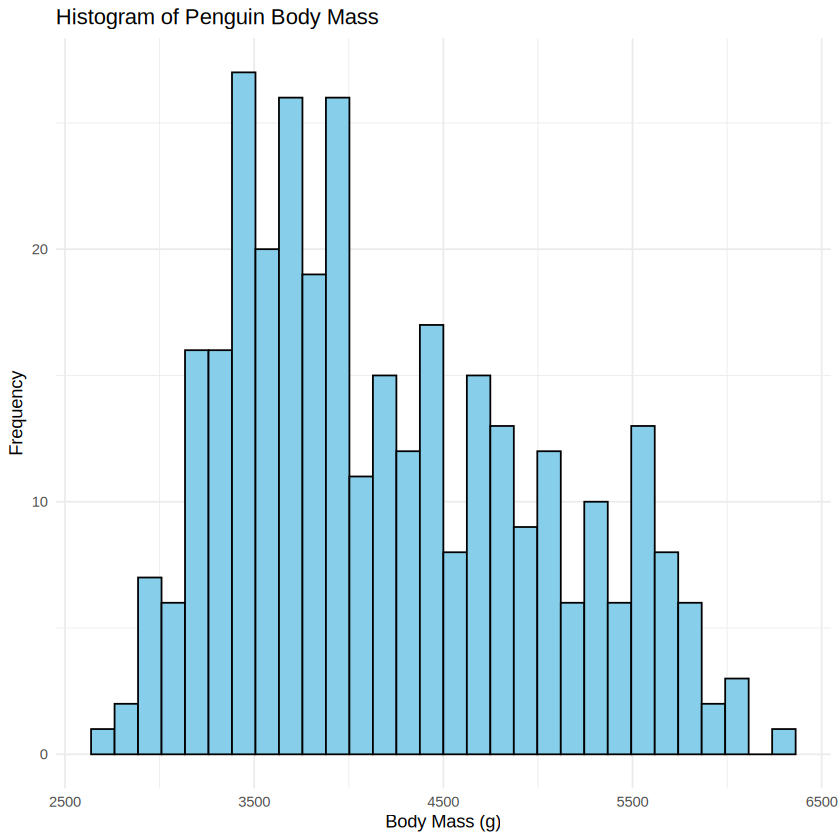

In [ ]:
ggplot(penguins_clean, aes(x = body_mass_g)) +
  geom_histogram(bins = 30, fill = "skyblue", color = "black") +
  labs(title = "Histogram of Penguin Body Mass", x = "Body Mass (g)", y = "Frequency") +
  theme_minimal()

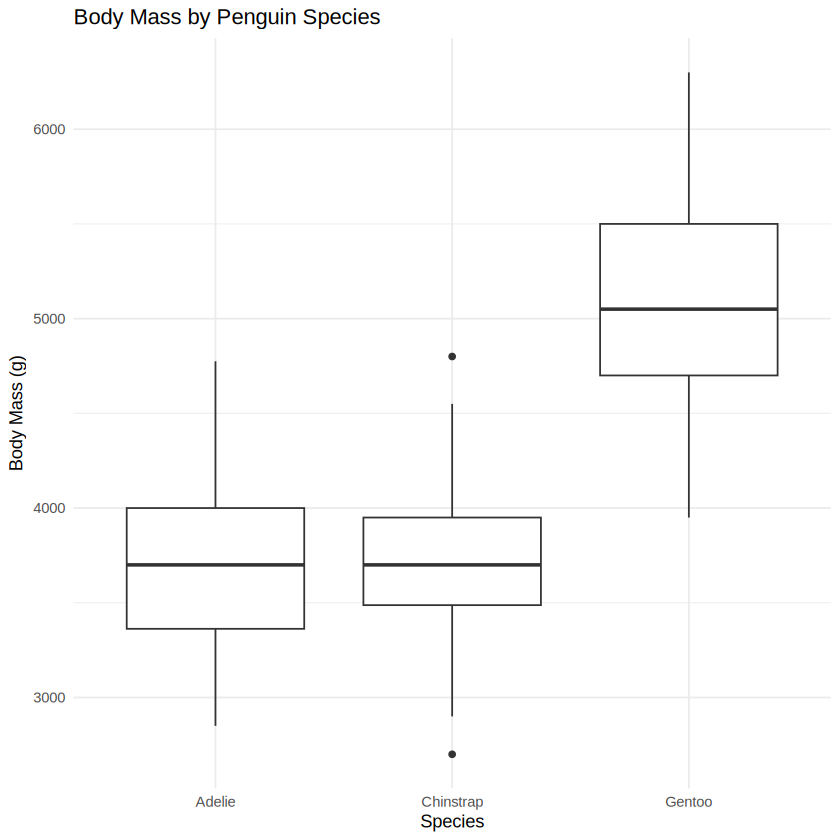

In [ ]:
ggplot(penguins_clean, aes(x = species, y = body_mass_g)) +
  geom_boxplot() +
  labs(title = "Body Mass by Penguin Species", x = "Species", y = "Body Mass (g)") +
  theme_minimal()

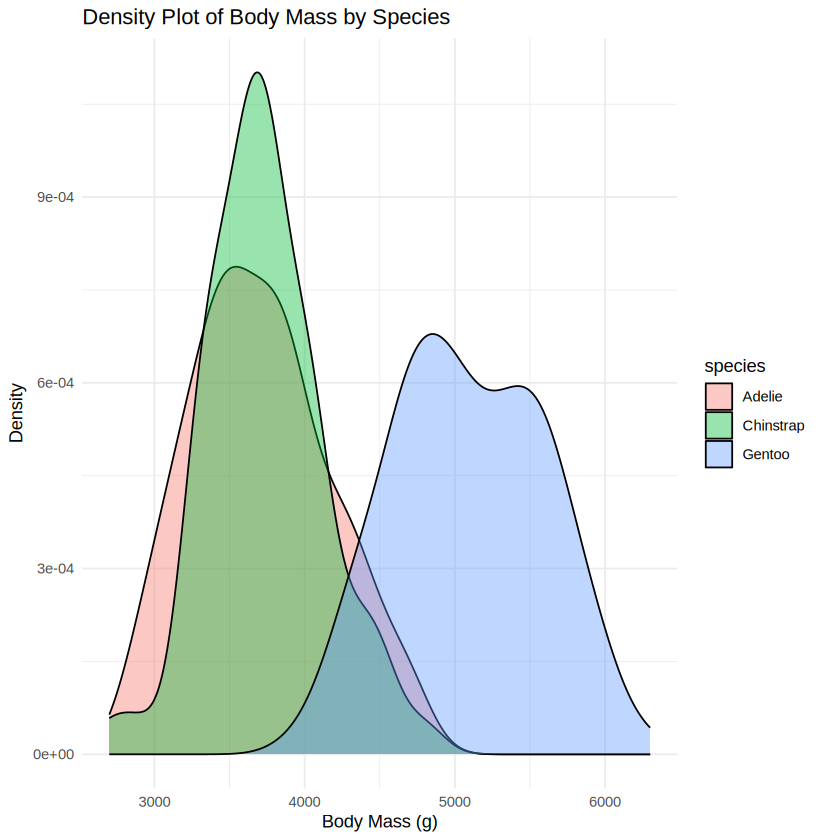

In [ ]:
ggplot(penguins_clean, aes(x = body_mass_g, fill = species)) +
  geom_density(alpha = 0.4) +
  labs(title = "Density Plot of Body Mass by Species", x = "Body Mass (g)", y = "Density") +
  theme_minimal()

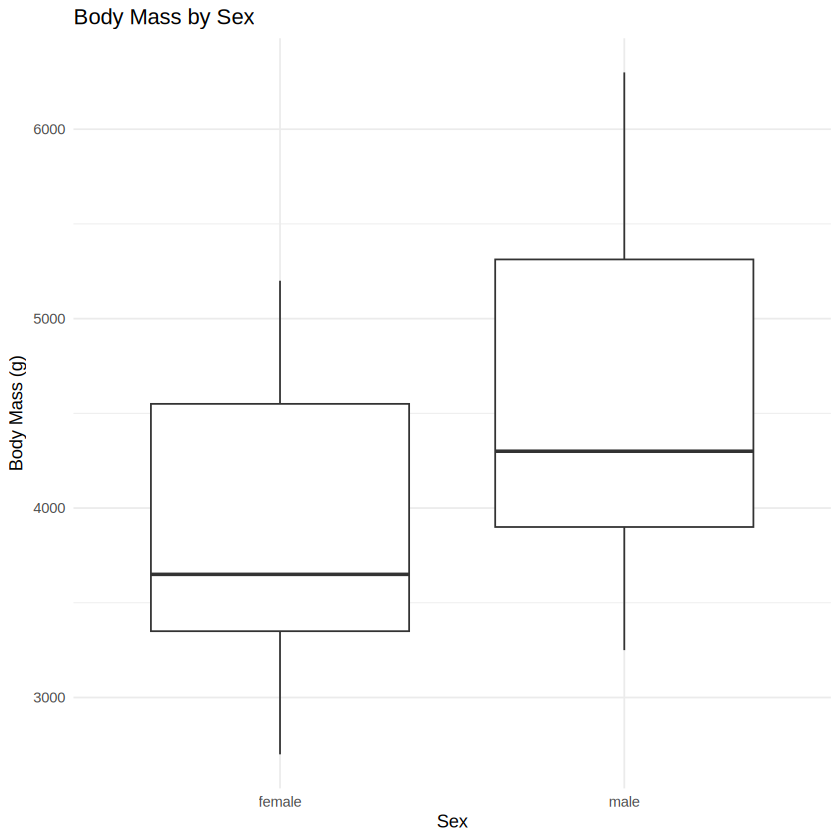

In [ ]:
ggplot(penguins_clean, aes(x = sex, y = body_mass_g)) +
  geom_boxplot() +
  labs(title = "Body Mass by Sex", x = "Sex", y = "Body Mass (g)") +
  theme_minimal()

## 3. Hypothesis Testing: Male vs Female Body Mass

In [ ]:
male <- penguins_clean %>% filter(sex == "male") %>% pull(body_mass_g)
female <- penguins_clean %>% filter(sex == "female") %>% pull(body_mass_g)

shapiro.test(male)
shapiro.test(female)


	Shapiro-Wilk normality test

data:  male
W = 0.92504, p-value = 1.227e-07



	Shapiro-Wilk normality test

data:  female
W = 0.91931, p-value = 6.155e-08


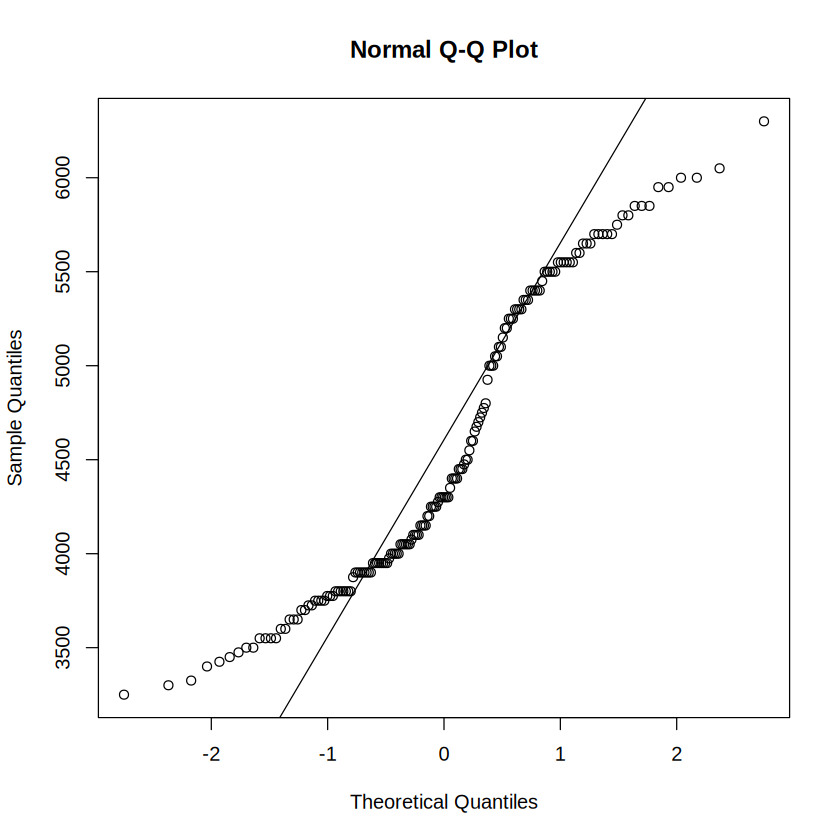

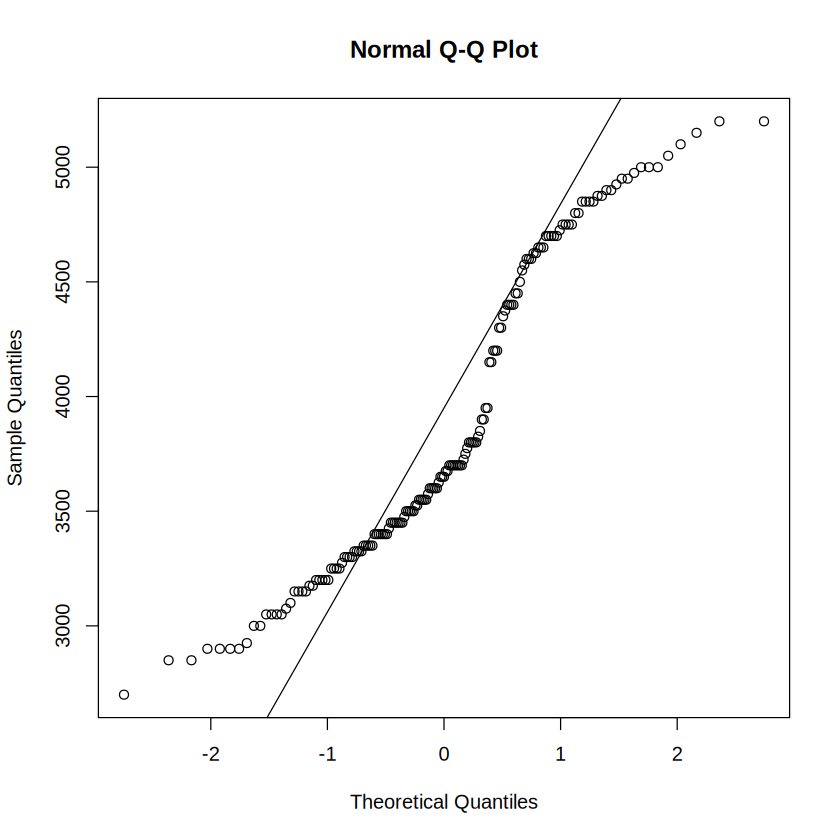

In [ ]:
qqnorm(male)
qqline(male)

qqnorm(female)
qqline(female)

In [ ]:
t_test_result <- t.test(body_mass_g ~ sex, data = penguins_clean, var.equal = FALSE)
t_test_result


	Welch Two Sample t-test

data:  body_mass_g by sex
t = -8.5545, df = 323.9, p-value = 4.794e-16
alternative hypothesis: true difference in means between group female and group male is not equal to 0
95 percent confidence interval:
 -840.5783 -526.2453
sample estimates:
mean in group female   mean in group male 
            3862.273             4545.685 


In [ ]:
cohen_d <- cohens_d(body_mass_g ~ sex, data = penguins_clean)
cohen_d

Cohens_d,CI,CI_low,CI_high
<dbl>,<dbl>,<dbl>,<dbl>
-0.9362048,0.95,-1.161904,-0.709225


## 4. One-Way ANOVA

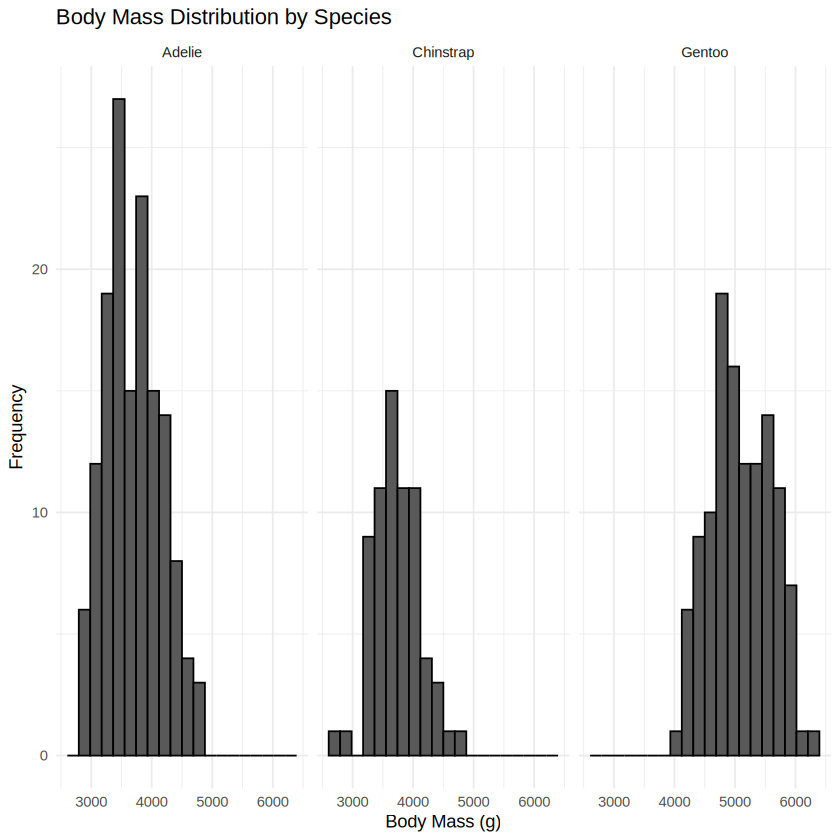

In [ ]:
ggplot(penguins_clean, aes(x = body_mass_g)) +
  geom_histogram(bins = 20, color = "black") +
  facet_wrap(~species) +
  labs(title = "Body Mass Distribution by Species", x = "Body Mass (g)", y = "Frequency") +
  theme_minimal()

In [ ]:
by(penguins_clean$body_mass_g, penguins_clean$species, shapiro.test)

penguins_clean$species: Adelie

	Shapiro-Wilk normality test

data:  dd[x, ]
W = 0.98116, p-value = 0.04232

------------------------------------------------------------ 
penguins_clean$species: Chinstrap

	Shapiro-Wilk normality test

data:  dd[x, ]
W = 0.98449, p-value = 0.5605

------------------------------------------------------------ 
penguins_clean$species: Gentoo

	Shapiro-Wilk normality test

data:  dd[x, ]
W = 0.98606, p-value = 0.2605


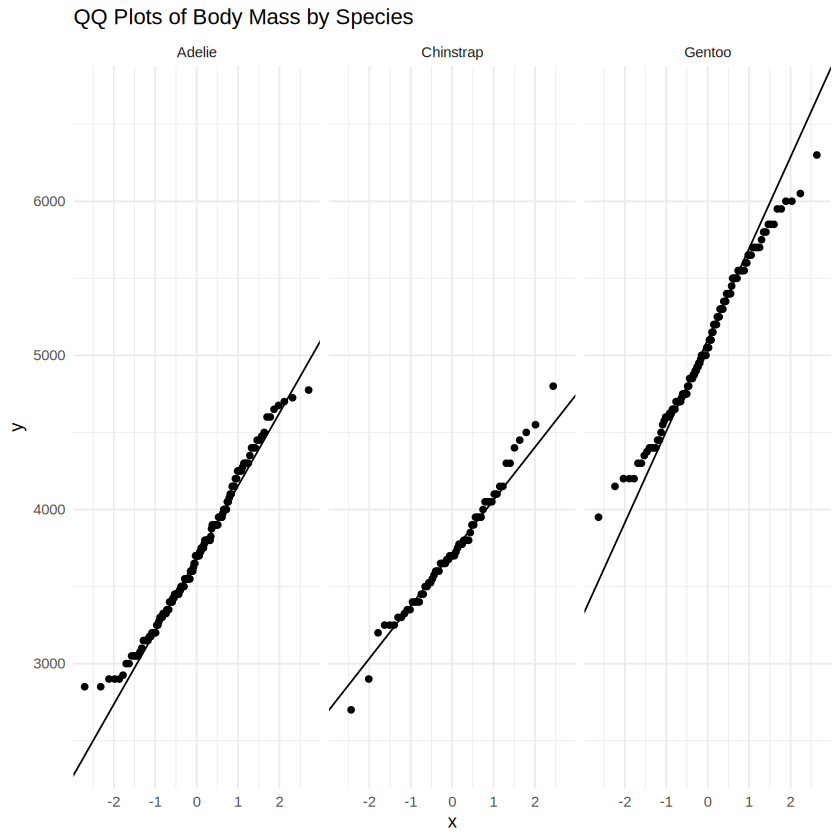

In [ ]:
ggplot(penguins_clean, aes(sample = body_mass_g)) +
  stat_qq() +
  stat_qq_line() +
  facet_wrap(~species) +
  labs(title = "QQ Plots of Body Mass by Species") +
  theme_minimal()

In [ ]:
leveneTest(body_mass_g ~ species, data = penguins_clean)

,Df,F value,Pr(>F)
,<int>,<dbl>,<dbl>
group,2,5.134899,0.006367054
,330,NA,NA


In [ ]:
anova_model <- aov(body_mass_g ~ species, data = penguins_clean)
summary(anova_model)

             Df    Sum Sq  Mean Sq F value Pr(>F)    
species       2 145190219 72595110   341.9 <2e-16 ***
Residuals   330  70069447   212332                   
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

In [ ]:
tukey_result <- TukeyHSD(anova_model)
tukey_result

  Tukey multiple comparisons of means
    95% family-wise confidence level

Fit: aov(formula = body_mass_g ~ species, data = penguins_clean)

$species
                       diff       lwr       upr    p adj
Chinstrap-Adelie   26.92385 -132.3528  186.2005 0.916431
Gentoo-Adelie    1386.27259 1252.2897 1520.2554 0.000000
Gentoo-Chinstrap 1359.34874 1194.4304 1524.2671 0.000000


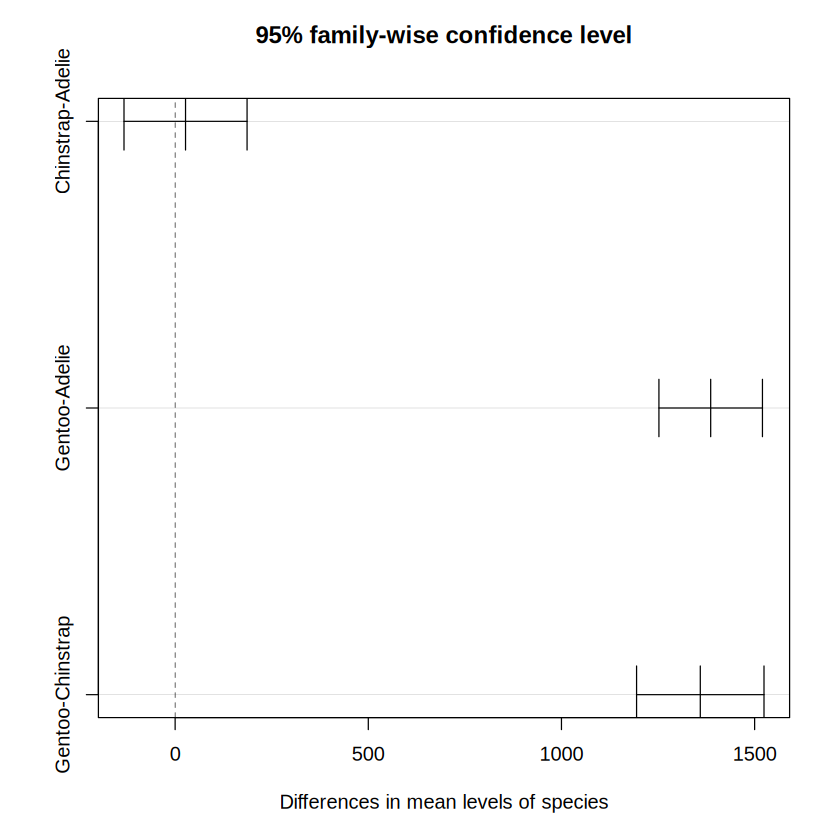

In [ ]:
plot(tukey_result)

## 5. Kruskal-Wallis Test

In [ ]:
kruskal_result <- kruskal.test(body_mass_g ~ species, data = penguins_clean)
kruskal_result


	Kruskal-Wallis rank sum test

data:  body_mass_g by species
Kruskal-Wallis chi-squared = 212.09, df = 2, p-value < 2.2e-16


## 6. Two-Way ANOVA

In [ ]:
two_way_model <- aov(body_mass_g ~ species * sex, data = penguins_clean)
summary(two_way_model)

             Df    Sum Sq  Mean Sq F value   Pr(>F)    
species       2 145190219 72595110 758.358  < 2e-16 ***
sex           1  37090262 37090262 387.460  < 2e-16 ***
species:sex   2   1676557   838278   8.757 0.000197 ***
Residuals   327  31302628    95727                     
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

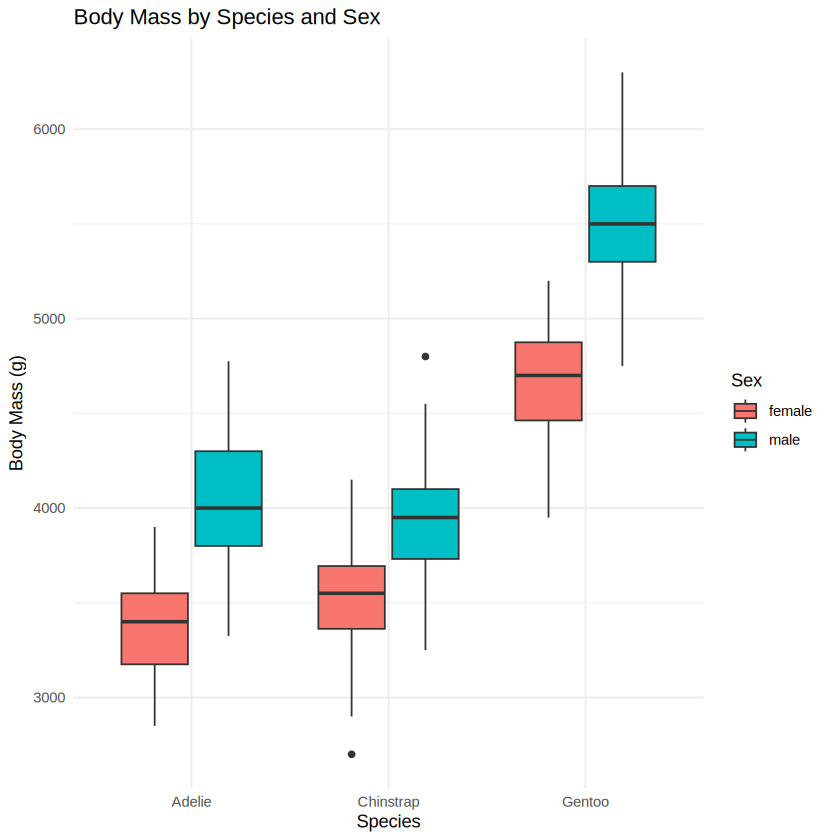

In [ ]:
ggplot(penguins_clean, aes(x = species, y = body_mass_g, fill = sex)) +
  geom_boxplot() +
  labs(title = "Body Mass by Species and Sex", x = "Species", y = "Body Mass (g)", fill = "Sex") +
  theme_minimal()

## 7. Flipper Length Analysis

In [ ]:
flipper_stats <- penguins_clean %>%
  group_by(species) %>%
  summarise(
    Mean = mean(flipper_length_mm),
    Median = median(flipper_length_mm),
    Minimum = min(flipper_length_mm),
    Maximum = max(flipper_length_mm),
    Variance = var(flipper_length_mm),
    SD = sd(flipper_length_mm),
    IQR = IQR(flipper_length_mm)
  )

flipper_stats

species,Mean,Median,Minimum,Maximum,Variance,SD,IQR
<fct>,<dbl>,<dbl>,<int>,<int>,<dbl>,<dbl>,<dbl>
Adelie,190.1027,190,172,210,42.53420,6.521825,9.0
Chinstrap,195.8235,196,178,212,50.86392,7.131894,10.0
Gentoo,217.2353,216,203,231,43.36790,6.585431,9.5


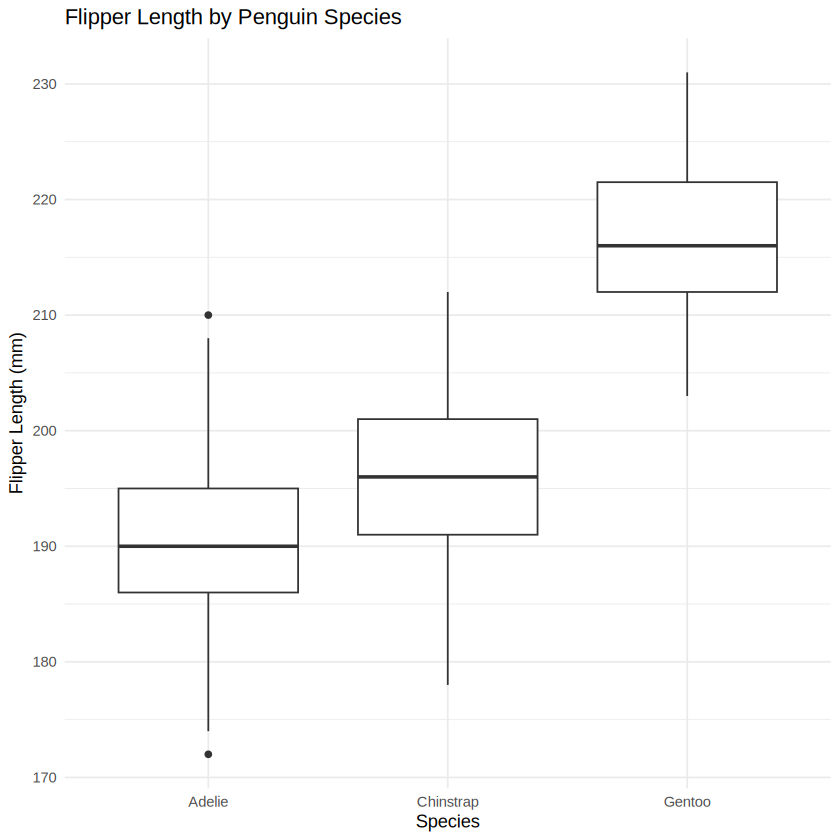

In [ ]:
ggplot(penguins_clean, aes(x = species, y = flipper_length_mm)) +
  geom_boxplot() +
  labs(title = "Flipper Length by Penguin Species", x = "Species", y = "Flipper Length (mm)") +
  theme_minimal()

In [ ]:
flipper_anova <- aov(flipper_length_mm ~ species, data = penguins_clean)
summary(flipper_anova)

             Df Sum Sq Mean Sq F value Pr(>F)    
species       2  50526   25263   567.4 <2e-16 ***
Residuals   330  14693      45                   
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

In [ ]:
TukeyHSD(flipper_anova)

  Tukey multiple comparisons of means
    95% family-wise confidence level

Fit: aov(formula = flipper_length_mm ~ species, data = penguins_clean)

$species
                     diff       lwr       upr p adj
Chinstrap-Adelie  5.72079  3.414364  8.027215     0
Gentoo-Adelie    27.13255 25.192399 29.072709     0
Gentoo-Chinstrap 21.41176 19.023644 23.799885     0


In [ ]:
kruskal.test(flipper_length_mm ~ species, data = penguins_clean)


	Kruskal-Wallis rank sum test

data:  flipper_length_mm by species
Kruskal-Wallis chi-squared = 237.35, df = 2, p-value < 2.2e-16


## 8. Final Comparison Plot

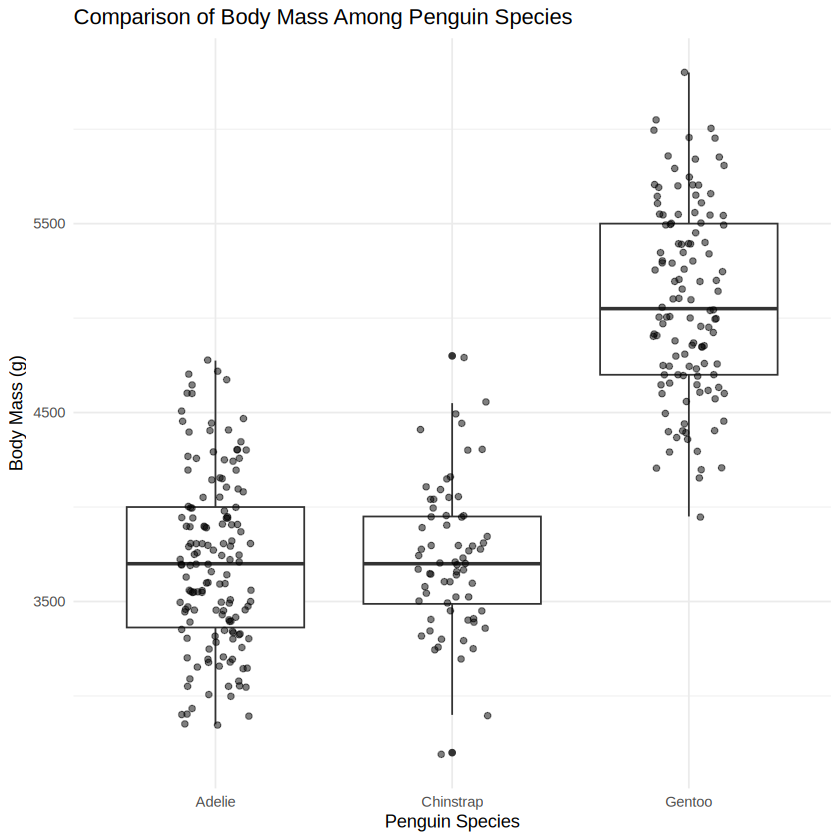

In [ ]:
ggplot(penguins_clean, aes(x = species, y = body_mass_g)) +
  geom_boxplot() +
  geom_jitter(width = 0.15, alpha = 0.5) +
  labs(title = "Comparison of Body Mass Among Penguin Species", x = "Penguin Species", y = "Body Mass (g)") +
  theme_minimal()